# Segment Events Budget Matrix Visualization

Heatmap of the budget matrix W = t_in - t_out, showing the free-window width per (pair, segment).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

import sys
sys.path.insert(0, '..')


from ksb.simulation.ksb_simulation import KSBSimulation

## Run simulation

In [2]:
# Load default config and adjust for visualization
config_path = Path("../configs/system/default.yaml")
with open(config_path) as f:
    cfg = yaml.safe_load(f)


print(f"Config: batch={cfg['batch']}, n_buffer_seg={cfg['n_buffer_seg']}")
print(f"Solver: {cfg.get('solver', 'scurve')}")

sim = KSBSimulation(cfg=cfg)
result = sim.run(seed=42)

W = result.segment_events.W
b = cfg['batch']
print(f"W shape: {W.shape}")
print(f"W range: [{W.min():.4f}, {W.max():.4f}]")

Config: batch=100, n_buffer_seg=7
Solver: ruckig
W shape: (99, 7)
W range: [-0.0613, 0.2582]


## Heatmap: Budget Matrix W

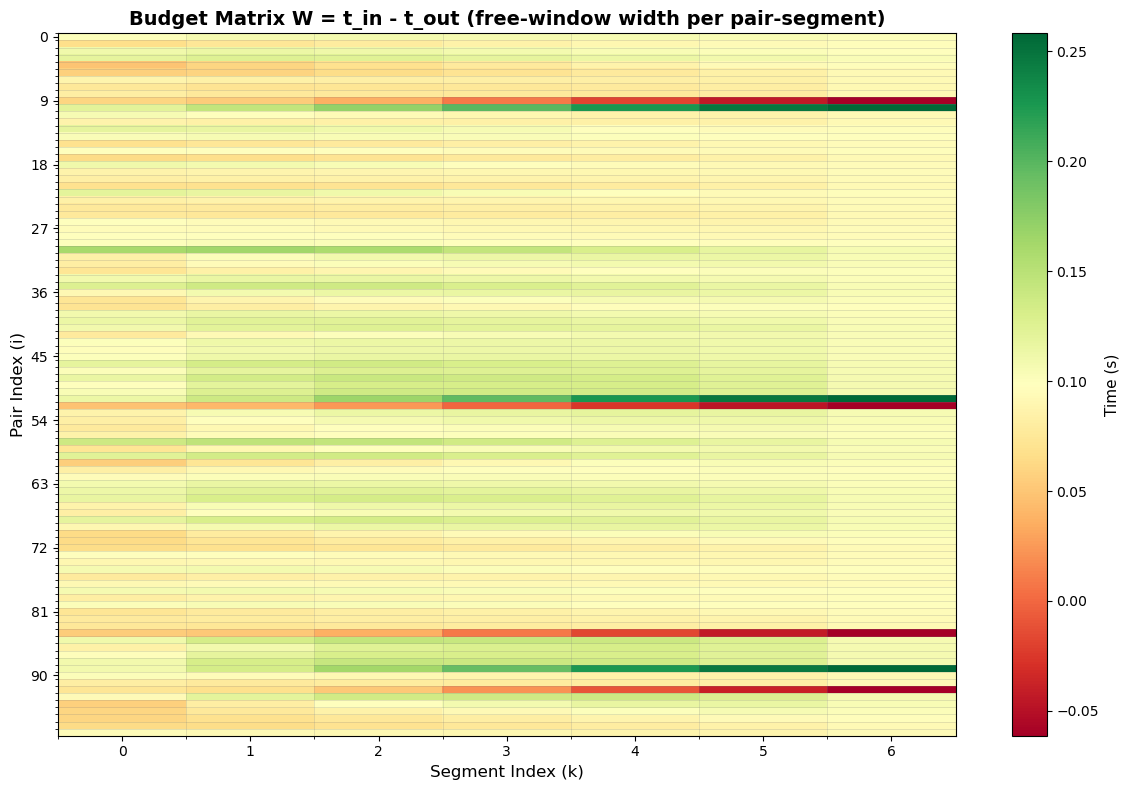

Heatmap saved to segment_events_W_heatmap.png


In [3]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap
im = ax.imshow(W, cmap="RdYlGn", aspect="auto", interpolation="nearest")

# Labels and title
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Pair Index (i)", fontsize=12)
ax.set_title("Budget Matrix W = t_in - t_out (free-window width per pair-segment)", fontsize=14, fontweight="bold")

# Ticks
ax.set_xticks(np.arange(W.shape[1]))
ax.set_yticks(np.arange(0, W.shape[0], max(1, W.shape[0]//10)))  # Sparse y-ticks

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Time (s)", fontsize=11)

# Grid
ax.set_xticks(np.arange(W.shape[1]) - 0.5, minor=True)
ax.set_yticks(np.arange(W.shape[0]) - 0.5, minor=True)
ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Heatmap saved to segment_events_W_heatmap.png")

## Summary Statistics

In [4]:
print("Budget Matrix W Statistics")
print("="*50)
print(f"Shape: {W.shape} (pairs × segments)")
print(f"Min value: {W.min():.6f} s")
print(f"Max value: {W.max():.6f} s")
print(f"Mean value: {W.mean():.6f} s")
print(f"Std dev: {W.std():.6f} s")
print()
print(f"Negative values (inverted windows): {np.sum(W < 0)} / {W.size}")
print(f"Positive values (normal windows): {np.sum(W > 0)} / {W.size}")
print()
print("Per-segment averages:")
for k in range(W.shape[1]):
    print(f"  Segment {k}: mean={W[:, k].mean():.6f} s, min={W[:, k].min():.6f} s, max={W[:, k].max():.6f} s")

Budget Matrix W Statistics
Shape: (99, 7) (pairs × segments)
Min value: -0.061296 s
Max value: 0.258188 s
Mean value: 0.099006 s
Std dev: 0.032697 s

Negative values (inverted windows): 13 / 693
Positive values (normal windows): 680 / 693

Per-segment averages:
  Segment 0: mean=0.090841 s, min=0.047336 s, max=0.160187 s
  Segment 1: mean=0.098567 s, min=0.041177 s, max=0.163891 s
  Segment 2: mean=0.101706 s, min=0.024334 s, max=0.170384 s
  Segment 3: mean=0.101801 s, min=-0.000602 s, max=0.198460 s
  Segment 4: mean=0.101877 s, min=-0.025540 s, max=0.226534 s
  Segment 5: mean=0.100544 s, min=-0.047323 s, max=0.247199 s
  Segment 6: mean=0.097703 s, min=-0.061296 s, max=0.258188 s


## Per-Pair Profile

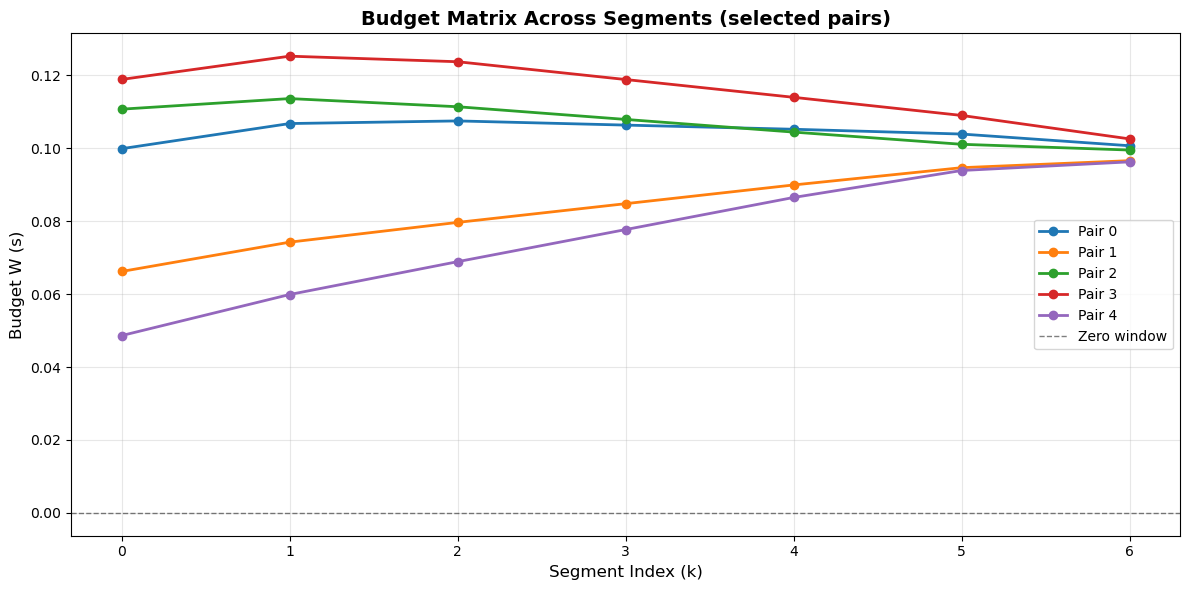

Profile plot saved to segment_events_W_profiles.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot W[i, :] for each pair as a line
for i in range(min(5, W.shape[0])):  # First 5 pairs
    ax.plot(W[i, :], marker="o", label=f"Pair {i}", linewidth=2, markersize=6)

ax.axhline(y=0, color="k", linestyle="--", linewidth=1, alpha=0.5, label="Zero window")
ax.set_xlabel("Segment Index (k)", fontsize=12)
ax.set_ylabel("Budget W (s)", fontsize=12)
ax.set_title("Budget Matrix Across Segments (selected pairs)", fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Profile plot saved to segment_events_W_profiles.png")

## Time Event Analysis

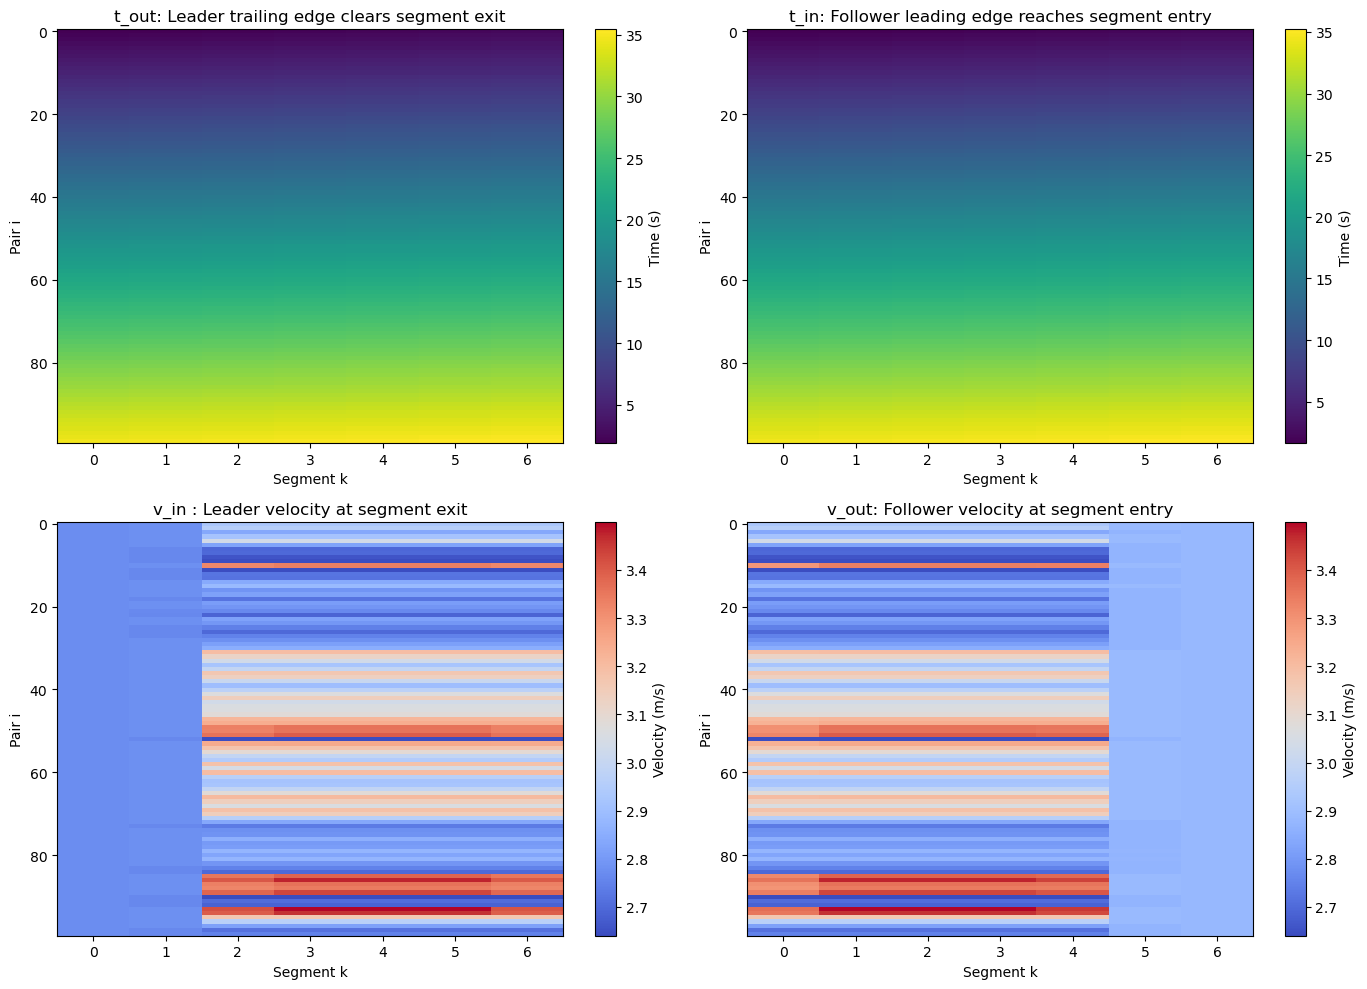

All event heatmaps saved to segment_events_all_heatmaps.png


In [6]:
t_out = result.segment_events.t_out
t_in = result.segment_events.t_in
v_in = result.segment_events.v_in
v_out = result.segment_events.v_out

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# t_out heatmap
im1 = axes[0, 0].imshow(t_out, cmap="viridis", aspect="auto")
axes[0, 0].set_title("t_out: Leader trailing edge clears segment exit")
axes[0, 0].set_xlabel("Segment k")
axes[0, 0].set_ylabel("Pair i")
plt.colorbar(im1, ax=axes[0, 0], label="Time (s)")

# t_in heatmap
im2 = axes[0, 1].imshow(t_in, cmap="viridis", aspect="auto")
axes[0, 1].set_title("t_in: Follower leading edge reaches segment entry")
axes[0, 1].set_xlabel("Segment k")
axes[0, 1].set_ylabel("Pair i")
plt.colorbar(im2, ax=axes[0, 1], label="Time (s)")

# v_in heatmap
im3 = axes[1, 0].imshow(v_in , cmap="coolwarm", aspect="auto")
axes[1, 0].set_title("v_in : Leader velocity at segment exit")
axes[1, 0].set_xlabel("Segment k")
axes[1, 0].set_ylabel("Pair i")
plt.colorbar(im3, ax=axes[1, 0], label="Velocity (m/s)")

# v_out heatmap
im4 = axes[1, 1].imshow(v_out, cmap="coolwarm", aspect="auto")
axes[1, 1].set_title("v_out: Follower velocity at segment entry")
axes[1, 1].set_xlabel("Segment k")
axes[1, 1].set_ylabel("Pair i")
plt.colorbar(im4, ax=axes[1, 1], label="Velocity (m/s)")

plt.tight_layout()
plt.show()

print("All event heatmaps saved to segment_events_all_heatmaps.png")

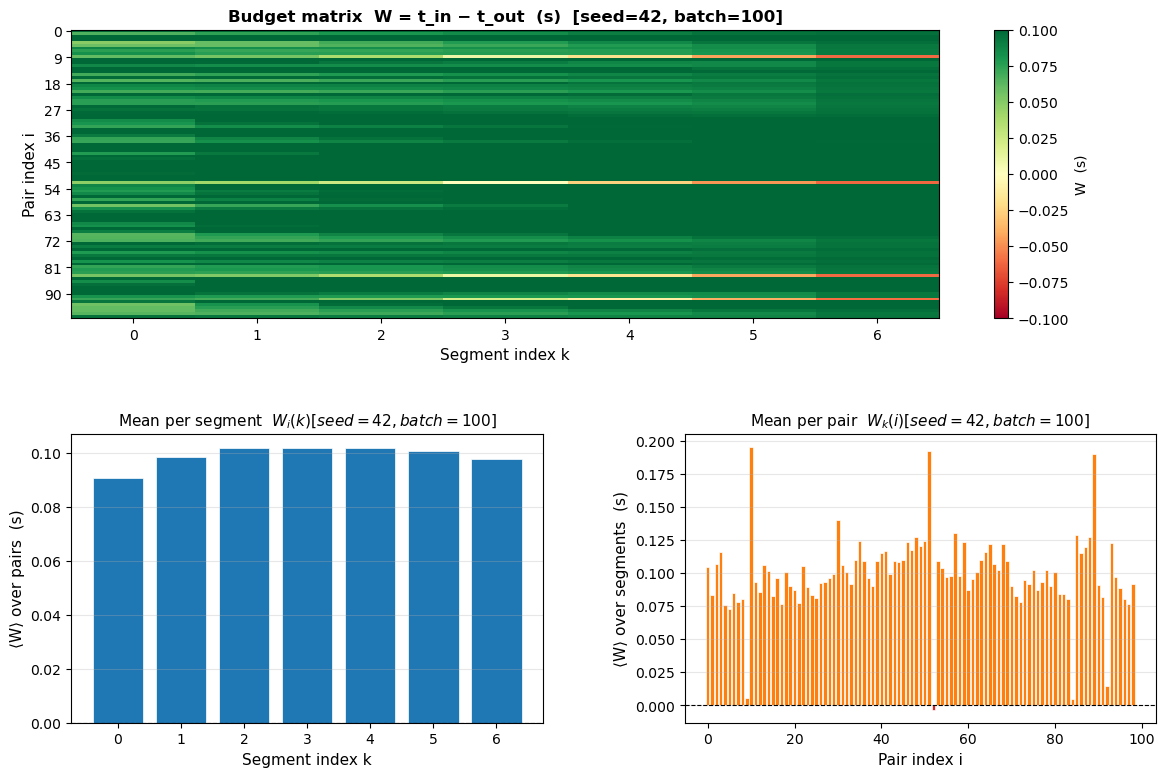

In [7]:
from ksb.visualization.segment_event_plots import plot_W_budget, plot_kinematic_margin, plot_pair_profile

fig = plot_W_budget(result.segment_events, title_suffix=f"seed=42, batch={cfg['batch']}")

## Budget histograms: mean W per segment k and per pair i

`plot_W_budget` shows the full heatmap plus the two marginal means:
- **⟨W⟩_i(k)** — mean budget over all pairs for each segment index k (blue bars; red = negative mean)
- **⟨W⟩_k(i)** — mean budget over all segments for each pair index i (orange bars; red = negative mean)

## Kinematic Margin

`kinematic_margin[i, k] = W[i, k] - T_min[i, k]`, where `T_min` is the Ruckig minimum-time duration to synchronize the leader's exit state `(v⁻, a⁻)` to the follower's entry state `(v⁺, a⁺)`. Positive = feasible; negative = window too tight for kinematic correction.

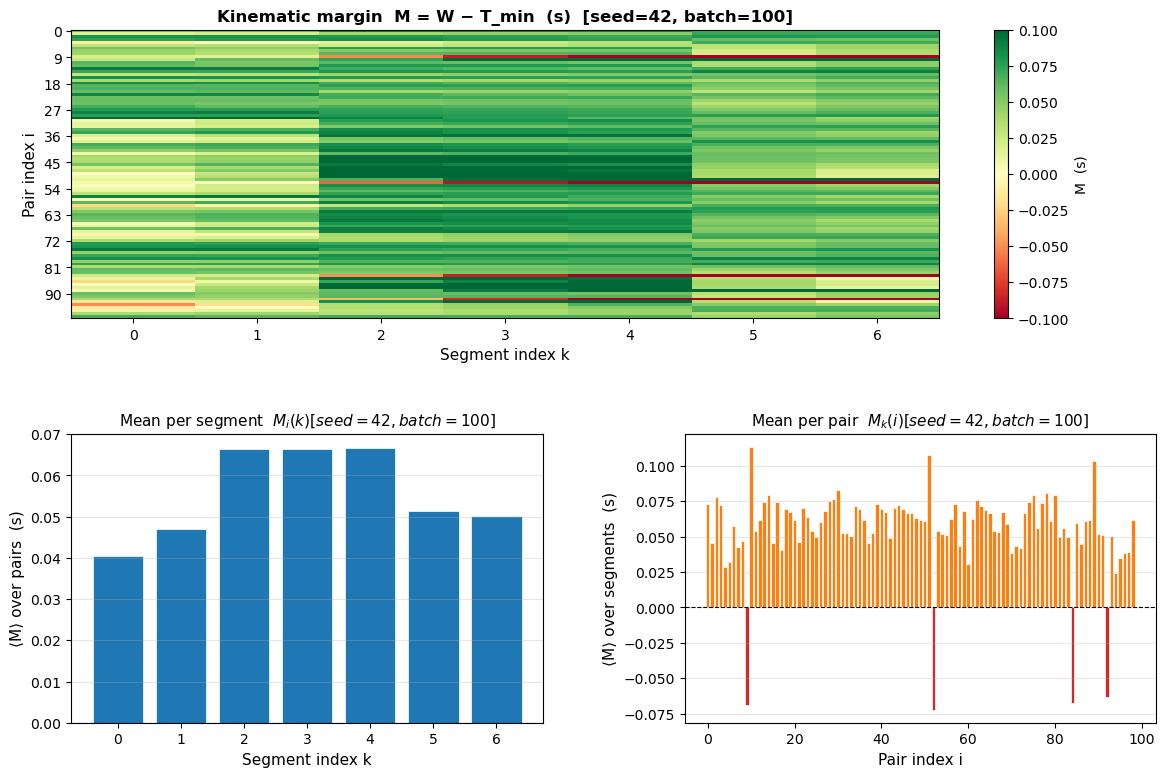

[ 1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74
 75 76 77 78 79 80 81 82 83 84 86 87 88 89 90 91 92 94 95 96 97 98 99]


In [8]:
fig = plot_kinematic_margin(result.segment_sync_response, title_suffix=f"seed=42, batch={cfg['batch']}")
print(result.skip_indices + 1)

(99, 7)


<BarContainer object of 7 artists>

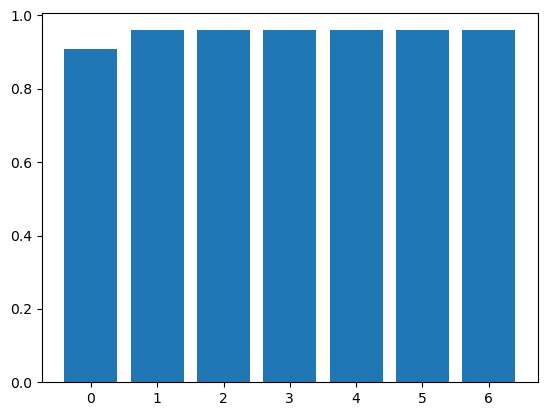

In [9]:
n_segments = cfg['n_buffer_seg']
margin = result.segment_sync_response.feasible
print(margin.shape)
event_pairs = margin.shape[0]
feasibility_rate = np.sum(margin, axis=0) / event_pairs
plt.bar(np.arange(n_segments), feasibility_rate)


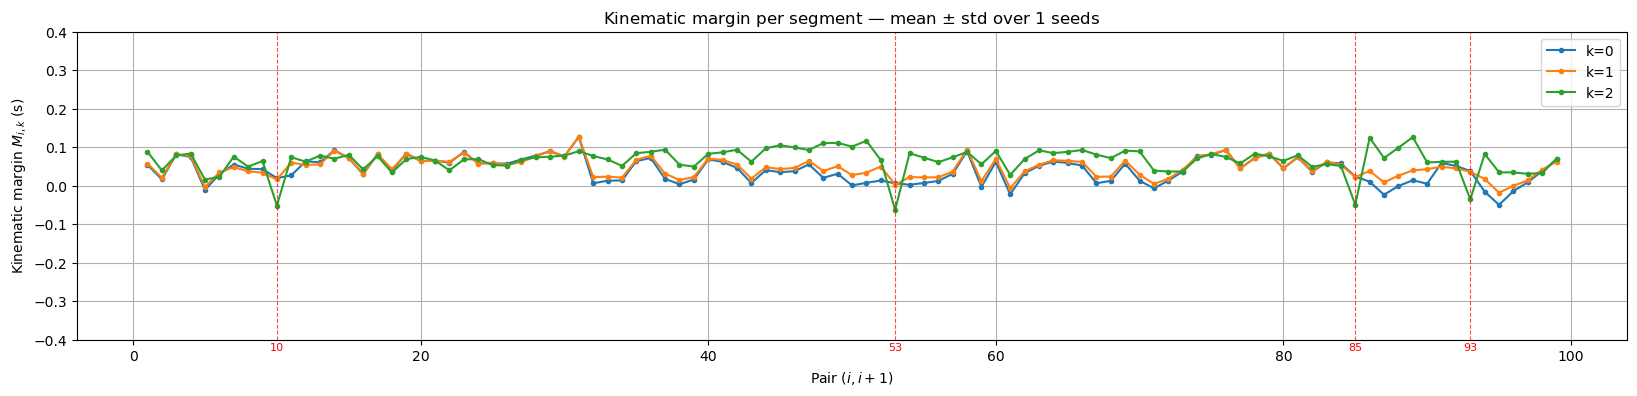

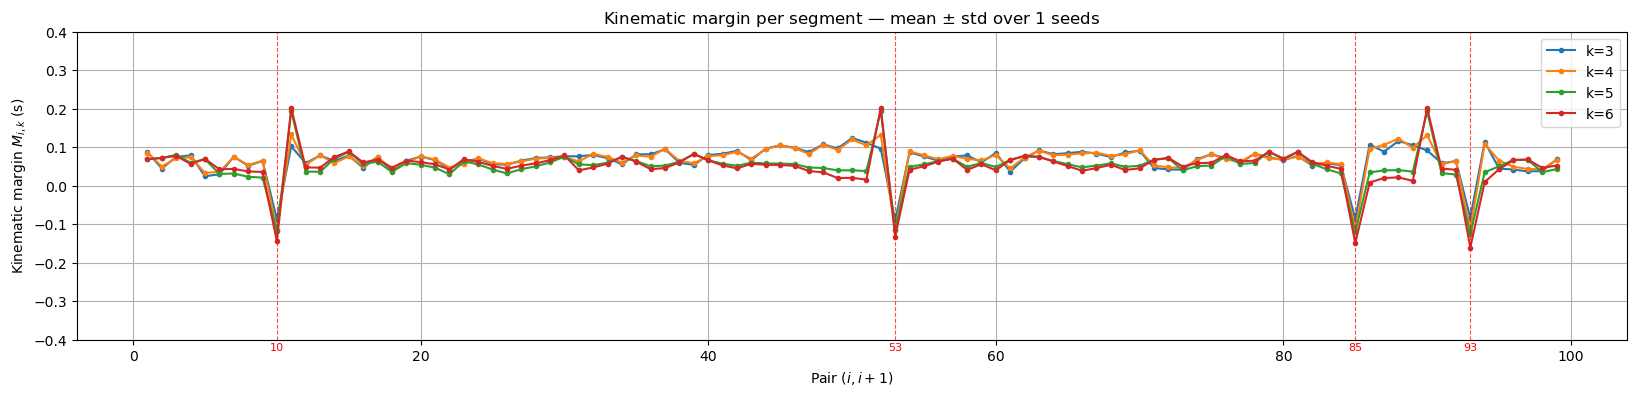

In [10]:
seeds = range(1)
margins = []
n_segments = cfg['n_buffer_seg']
markers = np.setdiff1d(np.arange(0, b-1), result.skip_indices)

for seed in seeds:
    result = sim.run(seed=seed+42)
    margins.append(result.segment_sync_response.kinematic_margin)

margins = np.stack(margins)  # (n_seeds, n_pairs, n_segments)

fig1, ax1 = plot_pair_profile(
    margins, markers,
    segments=range(min(3, n_segments)),
    ylabel="Kinematic margin $M_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)
fig2, ax2 = plot_pair_profile(
    margins, markers,
    segments=range(max(0,n_segments-4), n_segments),
    ylabel="Kinematic margin $M_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)

ax1.set_ylim(-.4, .4)
ax2.set_ylim(-.4, .4)
ax1.grid()
ax2.grid()
plt.show()

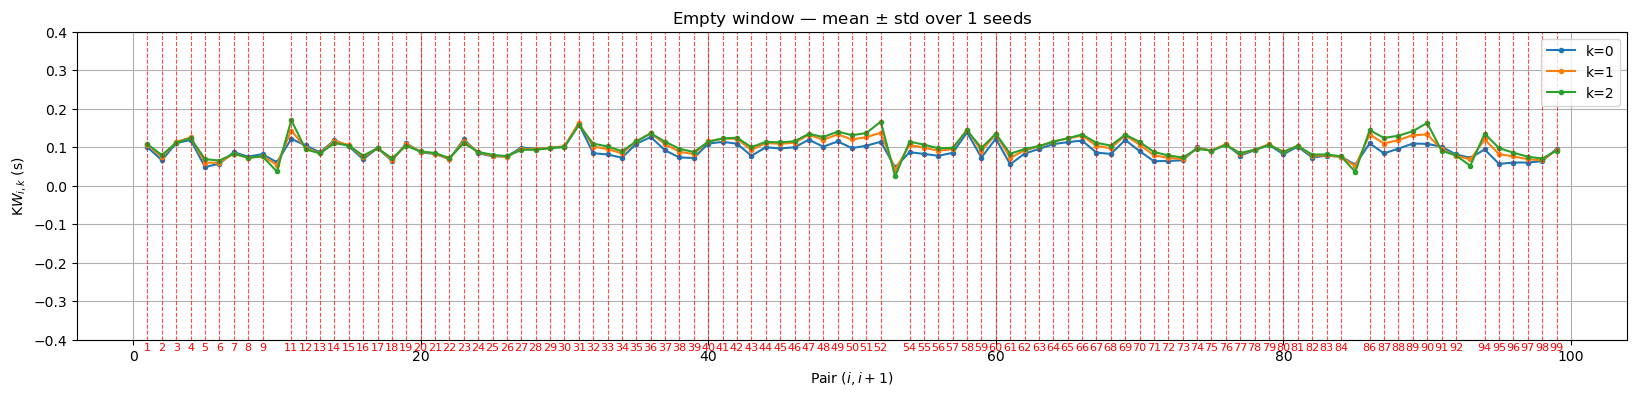

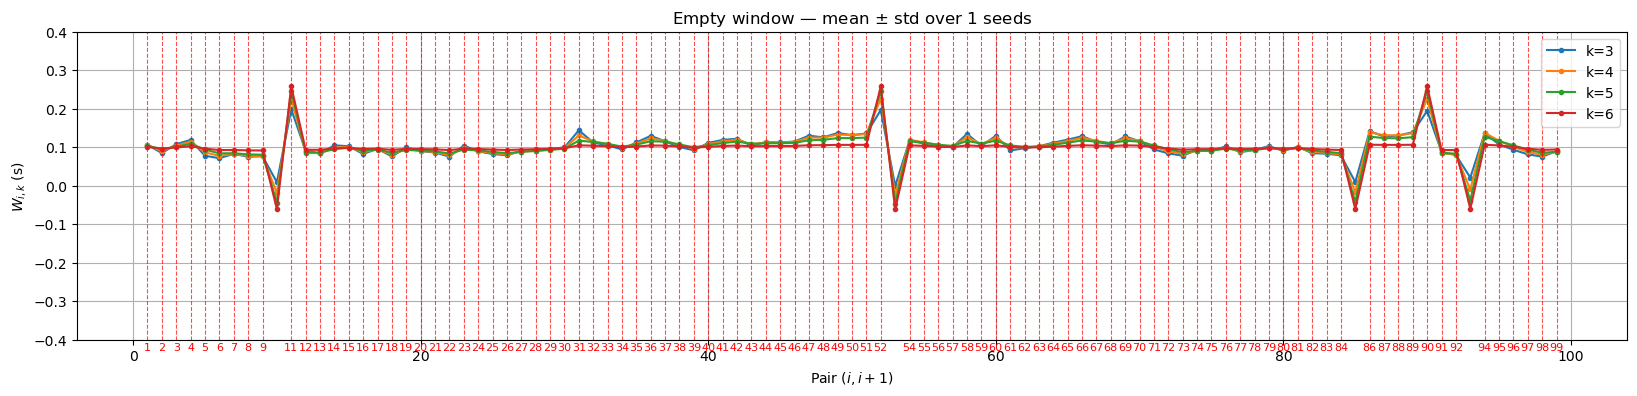

In [11]:
seeds = range(1)
margins = []
n_segments = cfg['n_buffer_seg']

for seed in seeds:
    result = sim.run(seed=seed+42)
    margins.append(result.segment_events.W)

margins = np.stack(margins)  # (n_seeds, n_pairs, n_segments)

fig1, ax1 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(min(3, n_segments)),
    ylabel="K$W_{i,k}$ (s)",
    title=f"Empty window — mean $\\pm$ std over {len(seeds)} seeds",
)
fig2, ax2 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(max(0,n_segments-4), n_segments),
    ylabel="$W_{i,k}$ (s)",
    title=f"Empty window — mean $\\pm$ std over {len(seeds)} seeds",
)

ax1.set_ylim(-.4, .4)
ax2.set_ylim(-.4, .4)
ax1.grid()
ax2.grid()
plt.show()

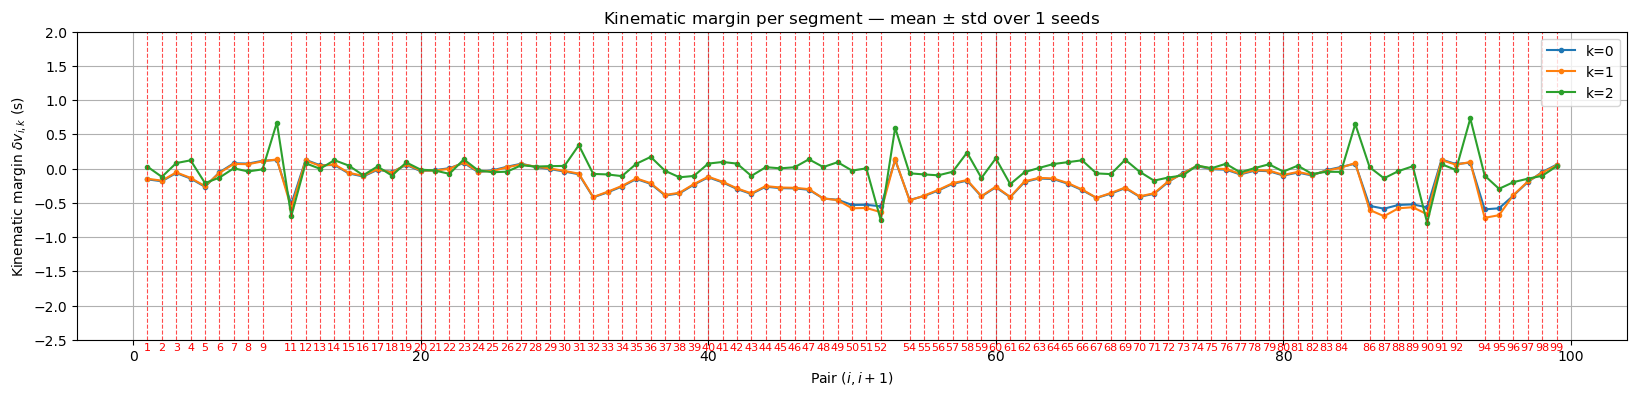

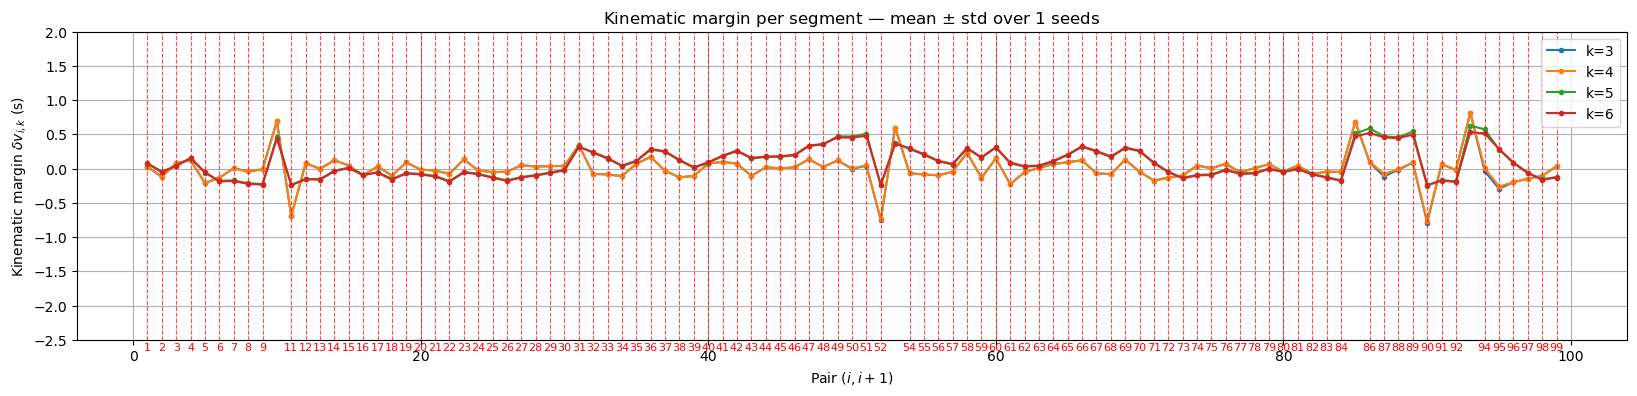

In [12]:
seeds = range(1)
margins = []

for seed in seeds:
    result = sim.run(seed=seed+42)
    v_in = result.segment_events.v_in
    v_out = result.segment_events.v_out
    margins.append(v_in[1:] - v_out[:-1])

margins = np.stack(margins)  # (n_seeds, n_pairs, n_segments)

fig1, ax1 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(min(3, n_segments)),
    ylabel="Kinematic margin $\\delta v_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)
fig2, ax2 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(max(0,n_segments-4), n_segments),
    ylabel="Kinematic margin $\\delta v_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)

ax1.set_ylim(-2.5, 2.0)
ax2.set_ylim(-2.5, 2.0)
ax1.grid()
ax2.grid()
plt.show()

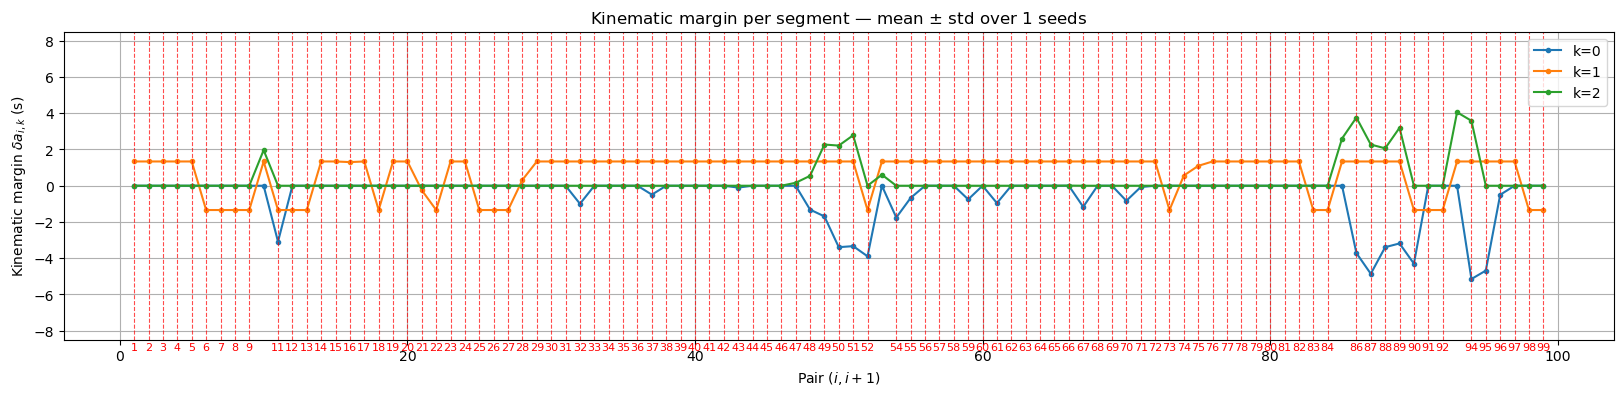

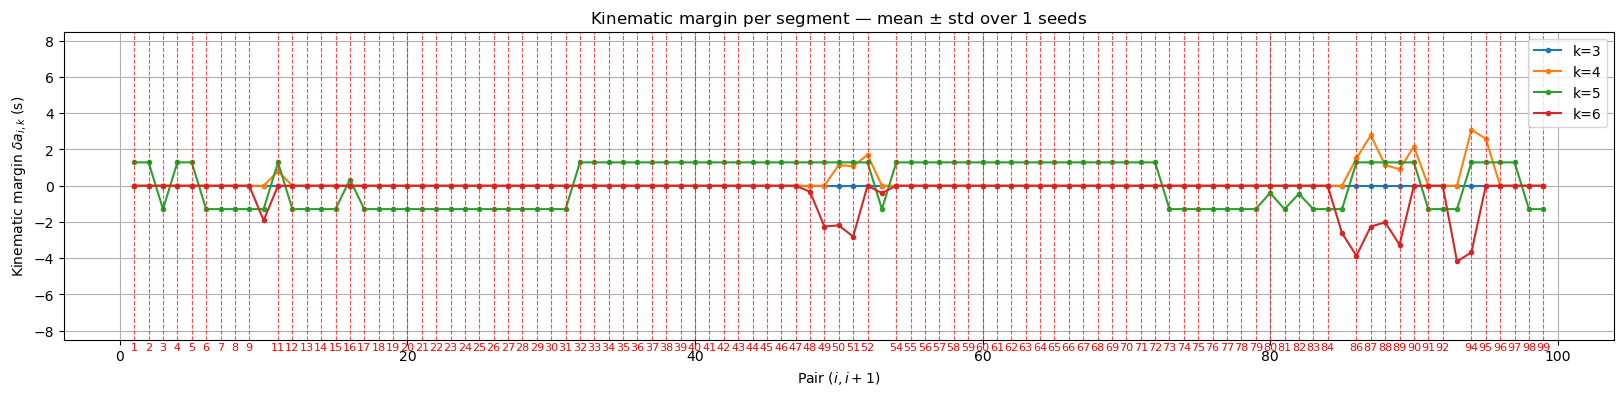

In [13]:
seeds = range(1)
margins = []
amax = cfg['Amax']

for seed in seeds:
    result = sim.run(seed=seed+42)
    a_in = result.segment_events.a_in
    a_out = result.segment_events.a_out
    margins.append(a_in[1:] - a_out[:-1])

margins = np.stack(margins)       # (n_seeds, n_pairs, n_segments)

fig1, ax1 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(min(3, n_segments)),
    ylabel="Kinematic margin $\\delta a_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)
fig2, ax2 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(max(0,n_segments-4), n_segments),
    ylabel="Kinematic margin $\\delta a_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)


ax1.set_ylim(-amax, amax)
ax2.set_ylim(-amax, amax)
ax1.grid()
ax2.grid()

plt.show()

(1, 99, 7)


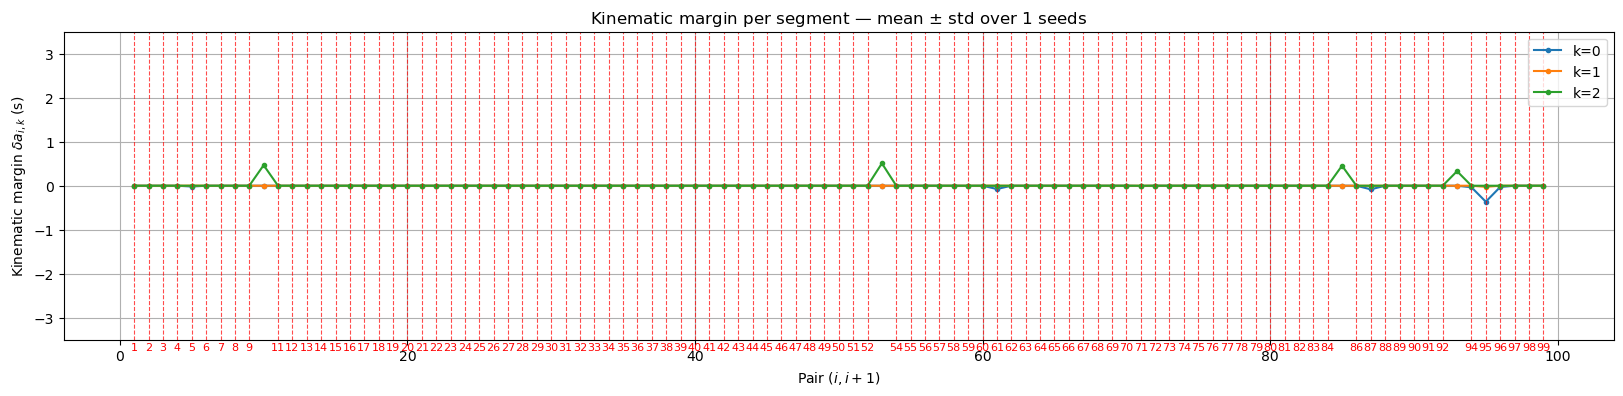

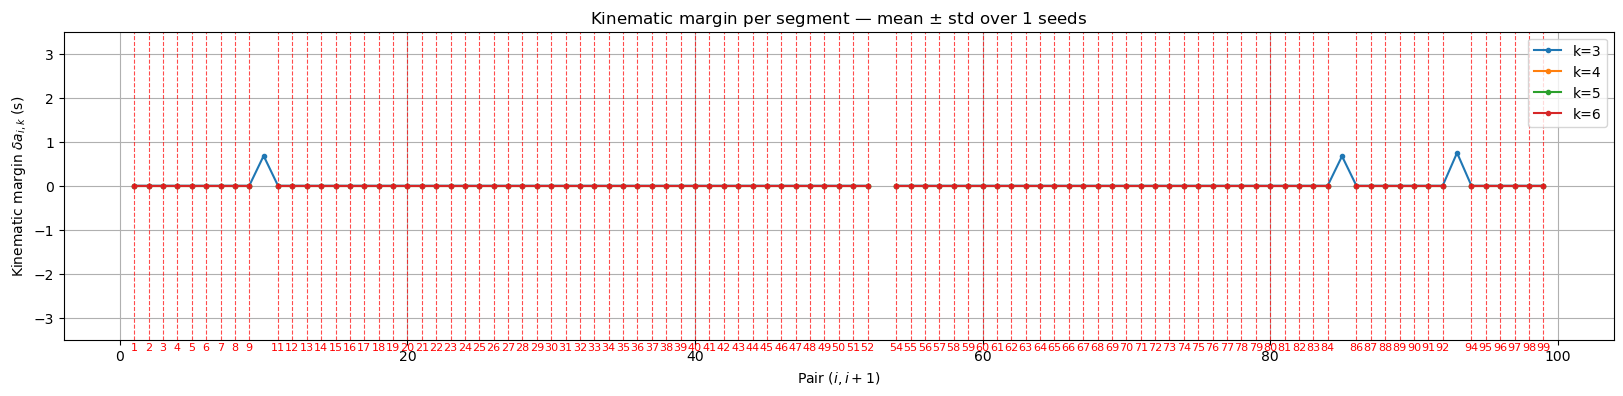

In [14]:
seeds = range(1)
margins = []
amax = cfg['Amax']
vmax = cfg['Vmax']

for seed in seeds:
    result = sim.run(seed=seed+42)
    margins.append(result.segment_sync_response.state_error[:,:,0]) # vel

margins = np.stack(margins)       # (n_seeds, n_pairs, n_segments)
print(margins.shape)

fig1, ax1 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(min(3, n_segments)),
    ylabel="Kinematic margin $\\delta a_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)
fig2, ax2 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(max(0,n_segments-4), n_segments),
    ylabel="Kinematic margin $\\delta a_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)


ax1.set_ylim(-vmax, vmax)
ax2.set_ylim(-vmax, vmax)
ax1.grid()
ax2.grid()

plt.show()

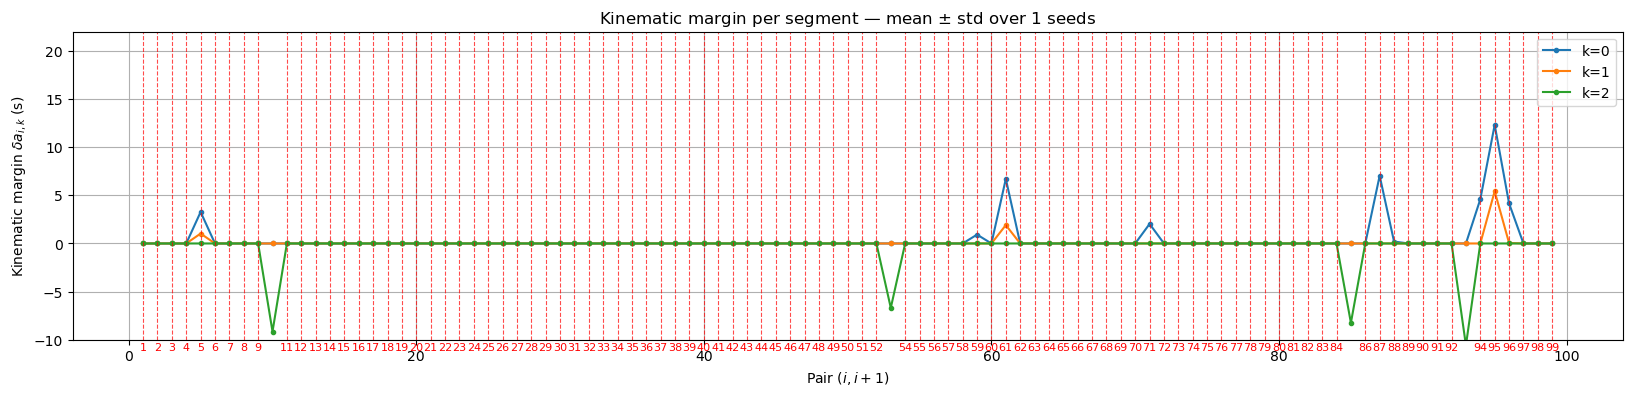

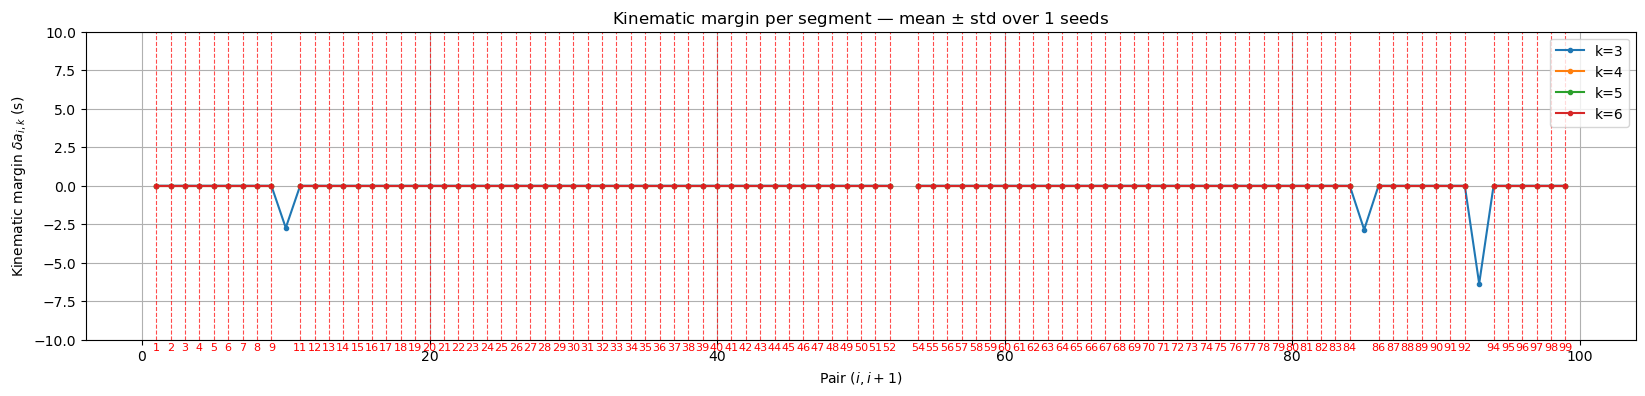

In [15]:
seeds = range(1)
margins = []
amax = cfg['Amax']

for seed in seeds:
    result = sim.run(seed=seed+42)
    margins.append(result.segment_sync_response.state_error[:,:,1]) # acc 

margins = np.stack(margins)       # (n_seeds, n_pairs, n_segments)

fig1, ax1 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(min(3, n_segments)),
    ylabel="Kinematic margin $\\delta a_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)
fig2, ax2 = plot_pair_profile(
    margins, result.skip_indices,
    segments=range(max(0,n_segments-4), n_segments),
    ylabel="Kinematic margin $\\delta a_{i,k}$ (s)",
    title=f"Kinematic margin per segment — mean $\\pm$ std over {len(seeds)} seeds",
)


ax1.set_ylim(-10, 22)
ax2.set_ylim(-10, 10)
ax1.grid()
ax2.grid()

plt.show()